# Logistic Regression: Cost Function and Gradient Implementation

In this coding exercise, you will be implementing the cost function and gradient function for linear regression. The cost function measures the error between the predicted values and the actual values, while the gradient function calculates the derivatives of the cost function with respect to the model parameters. You will use a synthetic dataset to test your code.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
np.random.seed(0)

# Generating two clouds of points from normal distributions
n_samples = 1000

# Generating points for the first group
mean1 = [1, -1]
cov1 = [[1, 0], [0, 1]]
cloud1 = np.random.multivariate_normal(mean1, cov1, n_samples)

# Generating points for the second group
mean2 = [-1, 1]
cov2 = [[1, 0], [0, 1]]
cloud2 = np.random.multivariate_normal(mean2, cov2, n_samples)

# Combining the two groups to create the feature matrix X
X = np.vstack((cloud1, cloud2))

# Generating the target variable y
y = np.concatenate((np.zeros(n_samples), np.ones(n_samples)))

# Splitting the data into training and testing sets
test_size = 0.2
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=0)

# Reshaping the target variables. What is the -1 used for?
y_train = y_train.reshape((-1, 1))
y_test = y_test.reshape((-1, 1))

# Printing the shapes of the training and testing sets
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print()
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1600, 2)
y_train shape: (1600, 1)

X_test shape: (400, 2)
y_test shape: (400, 1)


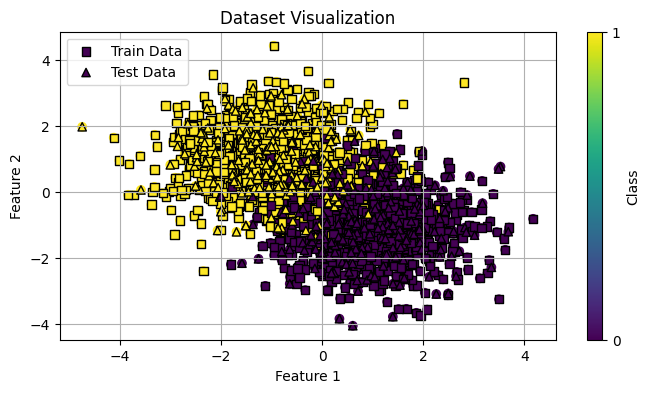

In [3]:
# Visualizing the dataset
plt.figure(figsize=(8, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
plt.title('Dataset Visualization')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(ticks=[0, 1], label='Class')
plt.grid(True)

# Plotting train data
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='viridis', edgecolor='black', linewidth=1, marker='s', label='Train Data')

# Plotting test data
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='viridis', edgecolor='black', linewidth=1, marker='^', label='Test Data')

# Setting legend
plt.legend()

# Showing the plot
plt.show()

In [10]:
import numpy as np
# import matplotlib.pyplot as plt  # uncomment if you need plotting

# Logistic regression prediction
def predict(X, theta):
    z = X @ theta
    probabilities = 1 / (1 + np.exp(-z))
    return probabilities


# Cost function
def cost_function(X, y, theta):
    n = len(y)

    probabilities = predict(X, theta)

    # avoid log(0) numerical issues
    epsilon = 1e-15
    probabilities = np.clip(probabilities, epsilon, 1 - epsilon)

    cost = -(1 / n) * (
        y.T @ np.log(probabilities) +
        (1 - y).T @ np.log(1 - probabilities)
    )

    return cost


# Gradient function
def gradient_function(X, y, theta):
    n = len(y)

    probabilities = predict(X, theta)

    gradient = (1 / n) * X.T @ (probabilities - y)

    return gradient


# Training function
def train_model(X_train, y_train, learning_rate, num_iterations):

    n, p = X_train.shape
    theta = np.zeros((p, 1))
    costs_train = []

    for _ in range(num_iterations):
        gradient = gradient_function(X_train, y_train, theta)
        theta -= learning_rate * gradient

        cost_train = cost_function(X_train, y_train, theta)
        costs_train.append(cost_train[0, 0])

    return theta, costs_train

In [11]:
# Generating artificial data for demonstration
np.random.seed(0)

# Training the logistic regression model
learning_rate = 0.01
num_iterations = 5000
theta_hat, costs_train = train_model(X_train, y_train, learning_rate, num_iterations)

#  predictions on the training data
probability_threshold = 1/2

probabilities_train = predict(X_train, theta_hat)
probabilities_test = predict(X_test, theta_hat)

y_train_pred = (probabilities_train >= probability_threshold).astype(int)
y_test_pred = (probabilities_test >= probability_threshold).astype(int)

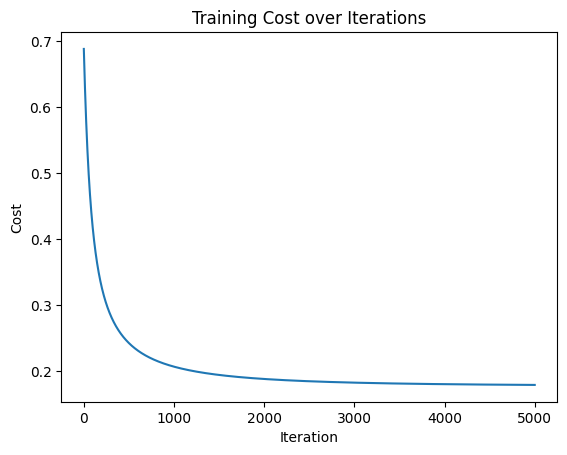

In [12]:
# Plotting the training costs
plt.plot(costs_train)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Training Cost over Iterations')
plt.show()

In [13]:
# Defining the precision function
def precision(y_true, y_pred):
    """
    Compute the precision score for binary classification.

    Parameters:
    y_true (numpy.ndarray): True target values of shape (n,).
    y_pred (numpy.ndarray): Predicted target values of shape (n,).

    Returns:
    precision (float): Precision score.
    """
    true_positives = np.sum((y_true == 1) & (y_pred == 1))
    false_positives = np.sum((y_true == 0) & (y_pred == 1))
    precision = true_positives / (true_positives + false_positives)

    return precision

# Defining the accuracy function
def accuracy(y_true, y_pred):
    """
    Compute the accuracy score for binary classification.

    Parameters:
    y_true (numpy.ndarray): True target values of shape (n,).
    y_pred (numpy.ndarray): Predicted target values of shape (n,).

    Returns:
    accuracy (float): Accuracy score.
    """
    correct_predictions = np.sum(y_true == y_pred)
    total_predictions = len(y_true)
    accuracy = correct_predictions / total_predictions

    return accuracy

In [14]:
#  precision for the training dataset
train_precision = precision(y_train, y_train_pred)

#  precision for the test dataset
test_precision = precision(y_test, y_test_pred)

#  accuracy for the training dataset
train_accuracy = accuracy(y_train, y_train_pred)

#  accuracy for the test dataset
test_accuracy = accuracy(y_test, y_test_pred)

# Print the results
print("Training Precision:", train_precision)
print("Training Accuracy:", train_accuracy)
print("Test Precision:", test_precision)
print("Test Accuracy:", test_accuracy)



Training Precision: 0.9154411764705882
Training Accuracy: 0.92375
Test Precision: 0.9095477386934674
Test Accuracy: 0.9075


In [15]:
def calculate_confusion_matrix(y_true, y_pred):
    """
    Calculate the confusion matrix for binary classification.

    Parameters:
    y_true (numpy.ndarray): True target values of shape (n,).
    y_pred (numpy.ndarray): Predicted target values of shape (n,).

    Returns:
    confusion_matrix (numpy.ndarray): Confusion matrix of shape (2, 2).
    """
    true_positive = np.sum(np.logical_and(y_true == 1, y_pred == 1))
    true_negative = np.sum(np.logical_and(y_true == 0, y_pred == 0))
    false_positive = np.sum(np.logical_and(y_true == 0, y_pred == 1))
    false_negative = np.sum(np.logical_and(y_true == 1, y_pred == 0))

    confusion_matrix = np.array([[true_negative, false_positive], [false_negative, true_positive]])
    return confusion_matrix


def plot_confusion_matrix(cm, classes, title):
    """
    Plot the confusion matrix.

    Parameters:
    cm (numpy.ndarray): Confusion matrix.
    classes (list): List of class labels.
    title (str): Title of the plot.
    """
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar(shrink=0.37)

    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    thresh = cm.max() / 2

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center", color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

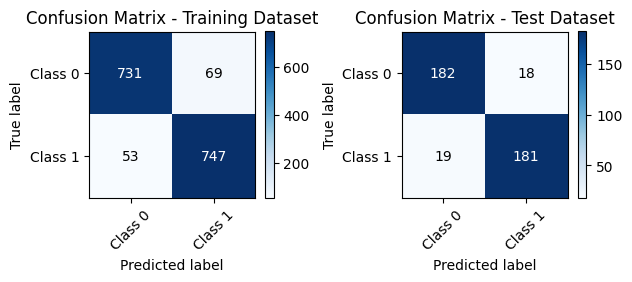

In [16]:
#  the confusion matrix for the training dataset
train_cm = calculate_confusion_matrix(y_train, y_train_pred)

#  the confusion matrix for the test dataset
test_cm = calculate_confusion_matrix(y_test, y_test_pred)

# Plotting the confusion matrix for the training dataset
plt.subplot(1, 2, 1)
plot_confusion_matrix(train_cm, classes=['Class 0', 'Class 1'], title='Confusion Matrix - Training Dataset')

# Plotting the confusion matrix for the test dataset
plt.subplot(1, 2, 2)
plot_confusion_matrix(test_cm, classes=['Class 0', 'Class 1'], title='Confusion Matrix - Test Dataset')

# Adjusting the layout and display the plot
plt.tight_layout()
plt.show()

Training Confusion Matrix
Test Confusion Matrix


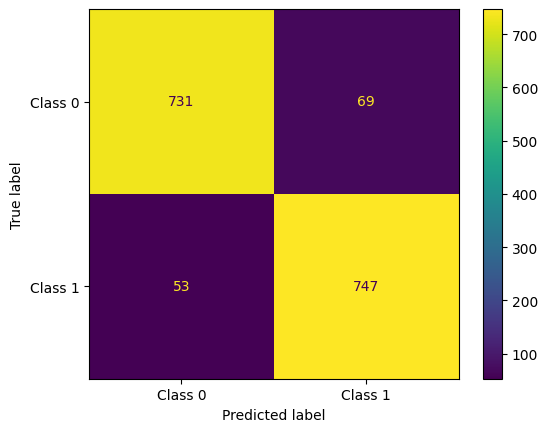

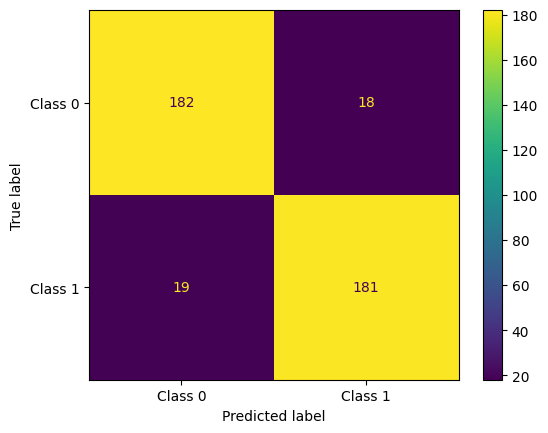

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Computing the confusion matrix for the training dataset
train_cm = confusion_matrix(y_train, y_train_pred)

# Computing the confusion matrix for the test dataset
test_cm = confusion_matrix(y_test, y_test_pred)

# Plotting the confusion matrix for the training dataset
print("Training Confusion Matrix")
ConfusionMatrixDisplay(train_cm, display_labels=['Class 0', 'Class 1']).plot()

# Plotting the confusion matrix for the test dataset
print("Test Confusion Matrix")
ConfusionMatrixDisplay(test_cm, display_labels=['Class 0', 'Class 1']).plot()

# Logistic Regression:  Breast cancer case study

In this exercise, we will fit logistic regression using our implementation and compare it that provided by scikit-learn. We will use the Breast Cancer Wisconsin dataset, split it into training and testing sets, and then train and evaluate the models' performance using precision and accuracy.

In [18]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Loadong the breast cancer dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Spliting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshaing the target variables. What is the -1 used for?
y_train = y_train.reshape((-1, 1))
y_test = y_test.reshape((-1, 1))

In [19]:
print(data.DESCR)

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [20]:
# Training: the logistic regression using custom implementation
learning_rate = 0.001
num_iterations = 1000
theta_hat, costs_train = train_model(X_train_scaled, y_train, learning_rate, num_iterations)

# Training: the logistic regression using scikit-learn
# Creating a logistic regression object
lr_sklearn = LogisticRegression()

# Training: the model on the scaled training data
lr_sklearn.fit(X_train_scaled, y_train)

#  the predictions for both models
y_pred_custom = (predict(X_test_scaled, theta_hat) >= 1/2).astype(int)
y_pred_sklearn = lr_sklearn.predict(X_test_scaled)

#  the precision and accuracy for both models
precision_custom = precision(y_test, y_pred_custom)
accuracy_custom = accuracy(y_test, y_pred_custom)

precision_sklearn = precision(y_test, y_pred_sklearn)
accuracy_sklearn = accuracy(y_test, y_pred_sklearn)

# Print the results
print("Custom Logistic Regression:")
print(f"Precision: {precision_custom}")
print(f"Accuracy: {accuracy_custom}")

print("\nScikit-learn Logistic Regression:")
print(f"Precision: {precision_sklearn}")
print(f"Accuracy: {accuracy_sklearn}")

Custom Logistic Regression:
Precision: 0.9857142857142858
Accuracy: 0.9736842105263158

Scikit-learn Logistic Regression:
Precision: 0.6228070175438597
Accuracy: 60.68421052631579


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
